In [3]:
import os
import shutil

# 1. Automatically find where Kaggle extracted your scripts
config_src = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'config.py' in files:
        config_src = os.path.join(root, 'config.py')
        src_dir = root
        break

if config_src is None:
    print("❌ Could not find config.py! Make sure the FAHM Scripts dataset was added.")
else:
    print(f"Found code in: {src_dir}")
    # Copy code to working directory so we can edit/run it
    shutil.copytree(src_dir, "/kaggle/working/model", dirs_exist_ok=True)

    # 2. Automatically find where Kaggle placed the CBIS-DDSM dataset
    dataset_root = None
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'jpeg' in dirs and 'csv' in dirs:
            dataset_root = root
            break
            
    if dataset_root is None:
        print("❌ Could not find the CBIS-DDSM dataset! Did you add it to the notebook?")
    else:
        print(f"Found dataset at: {dataset_root}")
        
        # 3. Update config.py paths automatically
        config_path = "/kaggle/working/model/config.py"
        with open(config_path, "r") as f:
            config_code = f.read()

        config_code = config_code.replace('./data/jpeg', f'{dataset_root}/jpeg')
        config_code = config_code.replace('./data/csv', f'{dataset_root}/csv')
        config_code = config_code.replace('../backend/app/models/model.pt', '/kaggle/working/model.pt')

        with open(config_path, "w") as f:
            f.write(config_code)

        print("\n✅ Setup complete! Run the next cell to start training.")

Found code in: /kaggle/input/datasets/adeelshah41/fahm-scripts
Found dataset at: /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset

✅ Setup complete! Run the next cell to start training.


In [4]:
!pip install -r /kaggle/working/model/requirements_train.txt
!python /kaggle/working/model/train.py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 93.2 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 

In [7]:
# ==========================================
# 1. Configuration (Auto-Detect Paths)
# ==========================================
import os

# Auto-discover the CBIS-DDSM dataset folder
dataset_root = None
for root, dirs, files in os.walk("/kaggle/input"):
    if "dicom_info.csv" in files:
        dataset_root = os.path.dirname(root) # The parent folder of /csv
        break

if not dataset_root:
    raise FileNotFoundError("Could not find the CBIS-DDSM dataset anywhere in /kaggle/input")

DATA_ROOT = os.path.join(dataset_root, "jpeg")
CSV_ROOT = os.path.join(dataset_root, "csv")

# Auto-discover the model
MODEL_SAVE_PATH = None
for root, dirs, files in os.walk("/kaggle/input"):
    if "model.pt" in files:
        MODEL_SAVE_PATH = os.path.join(root, "model.pt")
        break

if not MODEL_SAVE_PATH:
    raise FileNotFoundError("Could not find model.pt anywhere in /kaggle/input")

print(f"✅ Found Data: {DATA_ROOT}")
print(f"✅ Found CSVs: {CSV_ROOT}")
print(f"✅ Found Model: {MODEL_SAVE_PATH}")

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2 

VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
SEED = 42

PATHOLOGY_MAP = {
    "MALIGNANT": 1,
    "BENIGN": 0,
    "BENIGN_WITHOUT_CALLBACK": 0,
}

CSV_FILES = [
    "mass_case_description_train_set.csv",
    "mass_case_description_test_set.csv",
    "calc_case_description_train_set.csv",
    "calc_case_description_test_set.csv",
]

✅ Found Data: /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg
✅ Found CSVs: /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/csv
✅ Found Model: /kaggle/input/datasets/adeelshah41/fahm-trained-model/model.pt


Searching for dataset and model...
✅ Found Data: /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg
✅ Found CSVs: /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/csv
✅ Found Model: /kaggle/input/datasets/adeelshah41/fahm-trained-model/model.pt
Evaluating on Device: cuda
Preparing dataset (this might take a few seconds)...
Total Dataset Built: 3566 images (Malignant=1456, Benign=2110)
Isolated Test Set Size: 535
Loading model weights...
Running inference on test set... Please wait.

       EVALUATION RESULTS (KAGGLE)
  Accuracy:    0.7514
  Precision:   0.6763  (PPV)
  Recall:      0.7477  (Sensitivity / TPR)
  Specificity: 0.7539  (TNR)
  F1-Score:    0.7102
  AUC-ROC:     0.8417
--------------------------------------------------
  Confusion Matrix:
    TN=239  FP=78
    FN=55  TP=163

Classification Report:

              precision    recall  f1-score   support

      Benign       0.81      0.75      0.78       317
   Malignant       0.68   

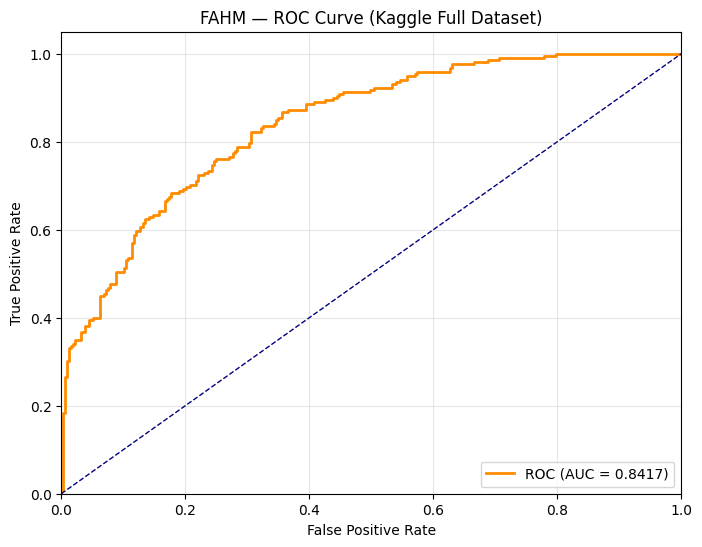

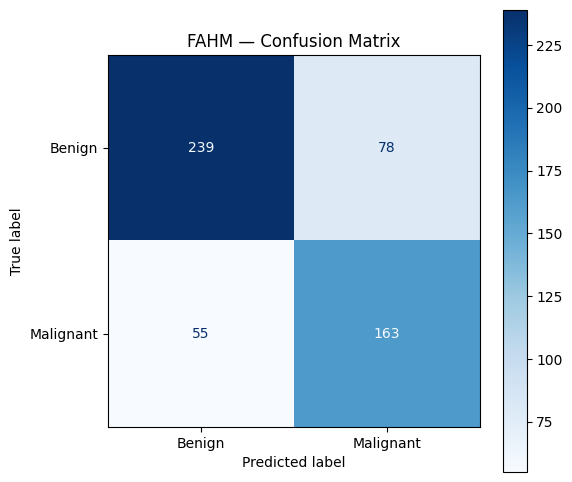

In [10]:
"""
Kaggle Evaluation Script for FAHM Mammogram Classifier
Run this directly in a Kaggle Notebook cell.
"""

import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)
import matplotlib.pyplot as plt

# ==========================================
# 1. Auto-Detect Configuration
# ==========================================
print("Searching for dataset and model...")

dataset_root = None
for root, dirs, files in os.walk("/kaggle/input"):
    if "dicom_info.csv" in files:
        dataset_root = os.path.dirname(root)
        break

if not dataset_root:
    raise FileNotFoundError("Could not find the CBIS-DDSM dataset anywhere in /kaggle/input")

DATA_ROOT = os.path.join(dataset_root, "jpeg")
CSV_ROOT = os.path.join(dataset_root, "csv")

MODEL_SAVE_PATH = None
for root, dirs, files in os.walk("/kaggle/input"):
    if "model.pt" in files:
        MODEL_SAVE_PATH = os.path.join(root, "model.pt")
        break

if not MODEL_SAVE_PATH:
    raise FileNotFoundError("Could not find model.pt anywhere in /kaggle/input")

print(f"✅ Found Data: {DATA_ROOT}")
print(f"✅ Found CSVs: {CSV_ROOT}")
print(f"✅ Found Model: {MODEL_SAVE_PATH}")

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2 

VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
SEED = 42

PATHOLOGY_MAP = {
    "MALIGNANT": 1,
    "BENIGN": 0,
    "BENIGN_WITHOUT_CALLBACK": 0,
}

CSV_FILES = [
    "mass_case_description_train_set.csv",
    "mass_case_description_test_set.csv",
    "calc_case_description_train_set.csv",
    "calc_case_description_test_set.csv",
]

# ==========================================
# 2. Dataset Preparation
# ==========================================
def _build_dicom_lookup(csv_root: str) -> dict:
    dicom_info_path = os.path.join(csv_root, "dicom_info.csv")
    df = pd.read_csv(dicom_info_path)
    cropped = df[df["SeriesDescription"].str.strip() == "cropped images"].copy()
    
    lookup = {}
    for _, row in cropped.iterrows():
        uid = str(row["SeriesInstanceUID"]).strip()
        img_path = str(row["image_path"]).strip()
        parts = img_path.replace("\\", "/").split("/")
        rel = "/".join(parts[2:]) if len(parts) >= 3 else img_path
        if uid not in lookup:
            lookup[uid] = rel
    return lookup

def _extract_series_uid(cropped_path: str):
    clean = cropped_path.strip().strip('"').strip()
    segments = clean.replace("\\", "/").split("/")
    if len(segments) >= 3:
        return segments[2]
    return None

def prepare_dataframe(data_root: str, csv_root: str) -> pd.DataFrame:
    lookup = _build_dicom_lookup(csv_root)
    records = []
    
    for csv_name in CSV_FILES:
        csv_path = os.path.join(csv_root, csv_name)
        if not os.path.isfile(csv_path): continue
        df = pd.read_csv(csv_path)
        crop_col = "cropped image file path"
        
        for _, row in df.iterrows():
            pathology = str(row["pathology"]).strip()
            if pathology not in PATHOLOGY_MAP: continue
            
            uid2 = _extract_series_uid(str(row[crop_col]))
            if not uid2: continue
            
            rel_jpeg = lookup.get(uid2)
            if not rel_jpeg: continue
            
            full_path = os.path.join(data_root, rel_jpeg)
            if not os.path.isfile(full_path):
                uid_folder = os.path.join(data_root, uid2)
                if os.path.isdir(uid_folder):
                    jpgs = [f for f in os.listdir(uid_folder) if f.lower().endswith((".jpg", ".jpeg"))]
                    if jpgs: full_path = os.path.join(uid_folder, jpgs[0])
                    else: continue
                else: continue
                    
            records.append({"image_path": full_path, "label": PATHOLOGY_MAP[pathology]})
            
    result = pd.DataFrame(records).drop_duplicates(subset="image_path").reset_index(drop=True)
    print(f"Total Dataset Built: {len(result)} images (Malignant={int((result['label']==1).sum())}, Benign={int((result['label']==0).sum())})")
    return result

class MammogramDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform: image = self.transform(image)
        return image, int(row["label"])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ==========================================
# 3. Model Logic
# ==========================================
def build_model(device):
    model = models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(in_features, 1),
    )
    return model.to(device)

# ==========================================
# 4. Evaluation Loop
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Evaluating on Device: {device}")

# Prepare Data
print("Preparing dataset (this might take a few seconds)...")
full_df = prepare_dataframe(DATA_ROOT, CSV_ROOT)

# Recreate the exact test split from training
train_df, temp_df = train_test_split(
    full_df, test_size=(VAL_SPLIT + TEST_SPLIT), stratify=full_df["label"], random_state=SEED
)
relative_test = TEST_SPLIT / (VAL_SPLIT + TEST_SPLIT)
_, test_df = train_test_split(
    temp_df, test_size=relative_test, stratify=temp_df["label"], random_state=SEED
)

print(f"Isolated Test Set Size: {len(test_df)}")

test_loader = DataLoader(
    MammogramDataset(test_df, transform=eval_transforms),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)

# Load Model
print("Loading model weights...")
model = build_model(device)
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device, weights_only=True))
model.eval()

all_labels, all_probs = [], []

print("Running inference on test set... Please wait.")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        all_probs.extend(probs.tolist())
        all_labels.extend(labels.numpy().flatten().tolist())

all_labels_np = np.array(all_labels)
all_probs_np = np.array(all_probs)
all_preds = (all_probs_np >= 0.5).astype(int)

# Calculate Metrics
accuracy = accuracy_score(all_labels_np, all_preds)
precision = precision_score(all_labels_np, all_preds, pos_label=1, zero_division=0)
recall = recall_score(all_labels_np, all_preds, pos_label=1, zero_division=0)
f1 = f1_score(all_labels_np, all_preds, pos_label=1, zero_division=0)

tn, fp, fn, tp = confusion_matrix(all_labels_np, all_preds, labels=[0, 1]).ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
auc_roc = roc_auc_score(all_labels_np, all_probs_np)

print("\n" + "="*50)
print("       EVALUATION RESULTS (KAGGLE)")
print("="*50)
print(f"  Accuracy:    {accuracy:.4f}")
print(f"  Precision:   {precision:.4f}  (PPV)")
print(f"  Recall:      {recall:.4f}  (Sensitivity / TPR)")
print(f"  Specificity: {specificity:.4f}  (TNR)")
print(f"  F1-Score:    {f1:.4f}")
print(f"  AUC-ROC:     {auc_roc:.4f}")
print("-" * 50)
print("  Confusion Matrix:")
print(f"    TN={tn}  FP={fp}")
print(f"    FN={fn}  TP={tp}")
print("="*50)

print("\nClassification Report:\n")
print(classification_report(all_labels_np, all_preds, target_names=["Benign", "Malignant"]))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(all_labels_np, all_probs_np)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC (AUC = {auc_roc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("FAHM — ROC Curve (Kaggle Full Dataset)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

from sklearn.metrics import ConfusionMatrixDisplay

# Plot Visual Confusion Matrix
cm = confusion_matrix(all_labels_np, all_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])

plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, values_format="d", ax=plt.gca())
plt.title("FAHM — Confusion Matrix")
plt.grid(False)
plt.show()